# Lineare Regression Naives Modell: Einkommen vorhersagen (`ConvertedTotalComp`)

Einkommen wird nur durch WorkExp und Country vorhergesagt

In [3]:
import pandas as pd
import numpy as np


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [4]:

df = pd.read_csv("../One-Hot-Encoded.csv")


q98 = df["ConvertedCompTotal"].dropna().quantile(0.98)
df = df[df["ConvertedCompTotal"] <= q98].copy()
print(df["ConvertedCompTotal"].describe())

df = df[df["ConvertedCompTotal"] > 0].copy()

bool_cols = df.select_dtypes(include=['bool']).columns

for col in bool_cols:
    df[col] = df[col].astype(int)
df.dtypes

# Droppe alles außer WorkExp und alle Country One-Hot-Encoding Spalten
country_cols = [col for col in df.columns if col.startswith("Country_")]
cols_to_keep = ["WorkExp"] + country_cols + ["ConvertedCompTotal"]
df = df[cols_to_keep].copy()

count     21785.000000
mean      86982.492836
std       63772.008524
min           0.000000
25%       40873.000000
50%       75924.190383
75%      120000.000000
max      331000.000000
Name: ConvertedCompTotal, dtype: float64


In [5]:
TARGET = "ConvertedCompTotal"

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
feature_cols = [c for c in num_cols if c != TARGET]

X = df[feature_cols].copy()
y = df[TARGET].copy()


# Konsistentes Dropna (X vollständig + y vorhanden)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

print("After dropna -> X:", X.shape, "y:", y.shape)
y.describe()

After dropna -> X: (20788, 176) y: (20788,)


count     20788.000000
mean      90655.054242
std       62761.592870
min           0.000060
25%       46712.000000
50%       80000.000000
75%      122619.000000
max      331000.000000
Name: ConvertedCompTotal, dtype: float64

In [6]:
y_model = y.astype(float)
y_model.head()

0     61659.84
1    105102.00
3     36435.36
4     60000.00
5    120000.00
Name: ConvertedCompTotal, dtype: float64

In [7]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_model,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

X_train.head()

Train: (16630, 176) Test: (4158, 176)


,WorkExp,Country_Afghanistan,Country_Albania,Country_Algeria,Country_Andorra,Country_Angola,Country_Antigua and Barbuda,Country_Argentina,Country_Armenia,Country_Australia,...,Country_United Republic of Tanzania,Country_United States of America,Country_Uruguay,Country_Uzbekistan,"Country_Venezuela, Bolivarian Republic of...",Country_Viet Nam,Country_Yemen,Country_Zambia,Country_Zimbabwe,Country_nan
9726,5.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
35136,20.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
72,15.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
21701,6.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19656,25.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ["WorkExp"]
dummy_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("dum", "passthrough", dummy_cols),
    ],
    remainder="drop"
)


In [9]:

scaler = StandardScaler()
X_train_sc = preprocess.fit_transform(X_train)
X_test_sc  = preprocess.transform(X_test)



In [10]:
clf = LinearRegression()
clf.fit(X_train_sc, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
predicted = clf.predict(X_test_sc)
expected = y_test


test_predict_mean = np.full(len(y_test), y_train.mean())
print("Baseline Mean RMSE:")
rmse_baseline = np.sqrt(mean_squared_error(expected, test_predict_mean))
print(rmse_baseline)

print ("RMSE:")
rmse = np.sqrt(mean_squared_error(expected, predicted))
print (rmse)
print("R^2:")
r2 = r2_score(expected, predicted)
print (r2)
print("MAE:")
mae = mean_absolute_error(expected, predicted)
print (mae)

Baseline Mean RMSE:
62812.51674783529
RMSE:
47975.626580915705
R^2:
0.4165412969118938
MAE:
34203.86060712087


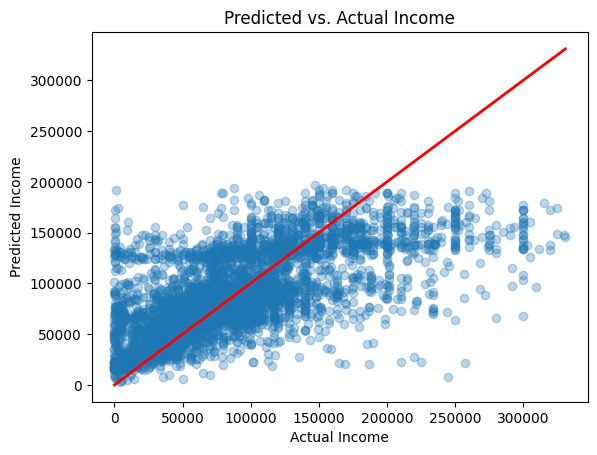

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(expected, predicted, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Predicted vs. Actual Income")
plt.show()



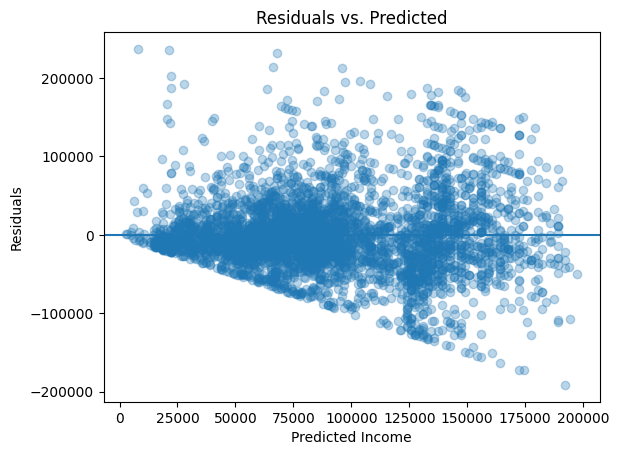

In [13]:
residuals = expected - predicted

plt.figure()
plt.scatter(predicted, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted Income")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted")
plt.show()


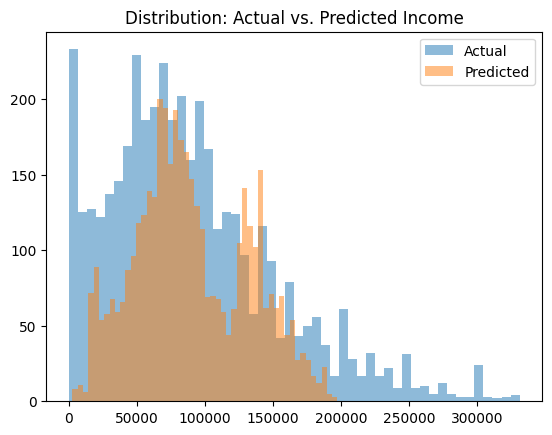

In [14]:
plt.figure()
plt.hist(expected, bins=50, alpha=0.5, label="Actual")
plt.hist(predicted, bins=50, alpha=0.5, label="Predicted")
plt.legend()
plt.title("Distribution: Actual vs. Predicted Income")
plt.show()
